# **Predicciones de valores con los primeros modelos**

Los datos financieros en bruto fueron preprocesados y limpiados previamente, dando lugar a una serie temporal estructurada adecuada para su uso en tareas de aprendizaje supervisado.

In [2]:
# =========================
# Core
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualización
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Preprocesado
# =========================
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# =========================
# Métricas
# =========================
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# Baselines / ML clásico
# =========================
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# =========================
# Deep Learning (Keras / TensorFlow)
# =========================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# Series temporales clásicas
# =========================
from statsmodels.tsa.arima.model import ARIMA

# =========================
# Utilidades
# =========================
import joblib
import os
import json
from datetime import datetime

# =========================
# Configuración global
# =========================
np.random.seed(42)
tf.random.set_seed(42)

plt.style.use("seaborn-v0_8")


In [4]:
# 1) Cargar datos
df = pd.read_csv("/content/AAPL_processed.csv", parse_dates=["date"])

# 2) Ordenar por fecha (muy importante en series temporales)
df = df.sort_values("date").reset_index(drop=True)

# 3) Comprobaciones básicas
print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nRango de fechas:", df["date"].min(), "→", df["date"].max())

# 4) Ver primeras filas
display(df.head())

# 5) Nulos
print("\nNulos por columna:\n", df.isna().sum())

# 6) Duplicados por fecha (si existieran)
dup_dates = df["date"].duplicated().sum()
print("\nFechas duplicadas:", dup_dates)

# 7) Estadísticas rápidas (para ver escalas)
display(df.describe())


Shape: (11366, 6)

Columnas: ['date', 'open', 'high', 'low', 'close', 'volume']

Rango de fechas: 1980-12-12 00:00:00 → 2026-01-16 00:00:00


,date,open,high,low,close,volume
0,1980-12-12,0.098389,0.098817,0.098389,0.098389,469033600
1,1980-12-15,0.093684,0.093684,0.093256,0.093256,175884800
2,1980-12-16,0.086839,0.086839,0.086412,0.086412,105728000
3,1980-12-17,0.088550,0.088978,0.088550,0.088550,86441600
4,1980-12-18,0.091118,0.091545,0.091118,0.091118,73449600



Nulos por columna:
 date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Fechas duplicadas: 0


,date,open,high,low,close,volume
count,11366,11366.000000,11366.000000,11366.000000,11366.000000,1.136600e+04
mean,2003-06-20 13:26:31.905683584,28.169320,28.473420,27.883312,28.190998,3.094768e+08
min,1980-12-12 00:00:00,0.038072,0.038072,0.037645,0.037645,0.000000e+00
25%,1992-03-10 06:00:00,0.246105,0.252562,0.240823,0.245770,1.061224e+08
50%,2003-06-17 12:00:00,0.484430,0.493933,0.473259,0.484096,1.986488e+08
75%,2014-09-29 18:00:00,21.579756,21.830166,21.362928,21.596613,3.897530e+08
max,2026-01-16 00:00:00,286.200012,288.619995,283.299988,286.190002,7.421641e+09
std,NaN,58.194807,58.814911,57.624541,58.247127,3.333446e+08


El conjunto de datos final consta de 11 366 observaciones diarias sin valores perdidos ni duplicados, lo que permite trabajar directamente sobre la serie temporal sin pasos adicionales de limpieza.

El objetivo del modelo es aproximar una función $f(\cdot)$ tal que:

$$
y_t = f(X_{t-1}, X_{t-2}, \dots, X_{t-k})
$$


Dado que las variables financieras presentan escalas muy diferentes (por ejemplo, volumen frente a precios), se aplica un proceso de normalización previo al entrenamiento del modelo con el fin de mejorar la estabilidad numérica y la convergencia durante el aprendizaje.


La normalización Min-Max transforma cada variable $x$ al intervalo $[0,1]$ según:

$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

donde $x_{\min}$ y $x_{\max}$ representan el valor mínimo y máximo de la variable en el conjunto de entrenamiento.


In [6]:
# =========================
# (RE)PASO 2: Features y target
# =========================

FEATURES = ["open", "high", "low", "close", "volume"]
TARGET = "close"

X_raw = df[FEATURES].values
y_raw = df[TARGET].values

print("Shape X_raw:", X_raw.shape)
print("Shape y_raw:", y_raw.shape)



Shape X_raw: (11366, 5)
Shape y_raw: (11366,)


In [7]:
from sklearn.preprocessing import MinMaxScaler

# Inicializar scaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Escalar features
X_scaled = scaler_X.fit_transform(X_raw)

# Escalar target (reshape obligatorio)
y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

print("X_scaled shape:", X_scaled.shape)
print("y_scaled shape:", y_scaled.shape)

X_scaled shape: (11366, 5)
y_scaled shape: (11366,)


Con el fin de evitar fugas de información (data leakage), los parámetros de normalización se estiman exclusivamente a partir del conjunto de entrenamiento y posteriormente se aplican al conjunto de validación y prueba.


## **Ventanas deslizantes**

Para transformar la serie temporal en un problema de aprendizaje supervisado, se emplea una ventana deslizante (*sliding window*) de tamaño $k$.
De este modo, cada ejemplo de entrada contiene las observaciones de los $k$ instantes anteriores y el objetivo es predecir el valor en el instante siguiente.


Sea $x_t \in \mathbb{R}^d$ el vector de variables observadas en el instante $t$ (en este caso, $d=5$ para OHLCV).  
Se define la entrada $X_t$ como la concatenación de los $k$ vectores previos:

$$
X_t = [x_{t-k}, x_{t-k+1}, \dots, x_{t-1}] \in \mathbb{R}^{k \times d}
$$

y el valor objetivo (a predecir) como:

$$
y_t = \text{close}_t
$$

Por tanto, el conjunto de entrenamiento se construye como pares $\{(X_t, y_t)\}$ para $t = k, \dots, T-1$.


In [8]:
def create_sliding_windows(X, y, window_size=20):
    """
    Construye ventanas temporales (sliding window).
    X: array (N, d)
    y: array (N,)
    Devuelve:
      X_seq: (N-window_size, window_size, d)
      y_seq: (N-window_size,)
    """
    X_seq, y_seq = [], []
    for t in range(window_size, len(X)):
        X_seq.append(X[t-window_size:t])
        y_seq.append(y[t])
    return np.array(X_seq), np.array(y_seq)

WINDOW_SIZE = 20

X_seq, y_seq = create_sliding_windows(X_scaled, y_scaled, window_size=WINDOW_SIZE)

print("X_seq shape:", X_seq.shape)  # (N-20, 20, 5)
print("y_seq shape:", y_seq.shape)  # (N-20,)


X_seq shape: (11346, 20, 5)
y_seq shape: (11346,)


In [9]:
print("Ejemplo 0 (ventana):", X_seq[0].shape)
print("Ejemplo 0 (target):", y_seq[0])

Ejemplo 0 (ventana): (20, 5)
Ejemplo 0 (target): 0.00023321199145883453


El tamaño de la ventana deslizante $k$ determina el número de observaciones pasadas utilizadas como entrada del modelo para predecir el valor futuro.


En este trabajo se utiliza inicialmente una ventana deslizante de tamaño $k=20$, lo que equivale aproximadamente a un mes de sesiones bursátiles, permitiendo capturar patrones recientes del mercado sin introducir información excesivamente antigua.


## **Split temporal**

Dado el carácter temporal de los datos financieros, la partición del conjunto de datos se realiza respetando el orden cronológico de las observaciones, con el objetivo de evitar fugas de información (*data leakage*) entre los conjuntos de entrenamiento y evaluación.

Sea $T$ el número total de ejemplos disponibles tras la construcción de ventanas temporales.
El conjunto de datos se divide en tres subconjuntos disjuntos:

$$
\mathcal{D}_{train} = \{(X_t, y_t)\}_{t=1}^{T_{train}}, \quad
\mathcal{D}_{val} = \{(X_t, y_t)\}_{t=T_{train}+1}^{T_{val}}, \quad
\mathcal{D}_{test} = \{(X_t, y_t)\}_{t=T_{val}+1}^{T}
$$

respetando en todo momento la secuencia temporal original.

Se emplea una división 70/15/15, lo que permite disponer de suficientes datos para el entrenamiento del modelo y, al mismo tiempo, evaluar su capacidad de generalización sobre datos no vistos.

In [10]:
# =========================
# PASO 5: Split temporal
# =========================

N = len(X_seq)

train_size = int(0.7 * N)
val_size = int(0.15 * N)

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]

X_val = X_seq[train_size:train_size + val_size]
y_val = y_seq[train_size:train_size + val_size]

X_test = X_seq[train_size + val_size:]
y_test = y_seq[train_size + val_size:]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (7942, 20, 5) (7942,)
Val:   (1701, 20, 5) (1701,)
Test:  (1703, 20, 5) (1703,)


In [11]:
print("Última fecha train:", df.iloc[train_size + WINDOW_SIZE - 1]["date"])
print("Primera fecha test:", df.iloc[train_size + val_size + WINDOW_SIZE]["date"])


Última fecha train: 2012-07-03 00:00:00
Primera fecha test: 2019-04-10 00:00:00


La partición temporal garantiza que el modelo es evaluado exclusivamente sobre observaciones futuras respecto a aquellas utilizadas durante el entrenamiento, reproduciendo un escenario realista de predicción financiera.

Los **modelos baseline** se utilizan como referencia para establecer un nivel mínimo de rendimiento en la tarea de predicción.
Su objetivo no es maximizar la precisión, sino proporcionar un punto de comparación que permita evaluar si modelos más complejos aportan mejoras reales sobre enfoques simples.

En este trabajo se emplean baselines clásicos en series temporales, como el modelo de persistencia, que asume que el mejor pronóstico para el siguiente instante es el último valor observado.

## **Baseline 1: (Naive/Persistence)**

Como línea base (*baseline*), se utiliza el método de persistencia (*persistence model*), que asume que el mejor pronóstico para el instante $t$ es el último valor observado.

Este enfoque sirve como referencia mínima: cualquier modelo más complejo debería mejorar este rendimiento para justificar su uso.

El modelo de persistencia se define como:

$$
\hat{y}_t = y_{t-1}
$$

donde $y_{t-1}$ es el último valor disponible en la ventana de entrada, y $\hat{y}_t$ es la predicción para el instante $t$.

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

CLOSE_IDX = FEATURES.index("close")

# Predicción naive: último 'close' de la ventana
y_pred_naive = X_test[:, -1, CLOSE_IDX]

# Métricas (en escala normalizada)
mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))

def smape(y_true, y_pred):
    eps = 1e-8
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + eps))

smape_naive = smape(y_test, y_pred_naive)

print("NAIVE BASELINE (escala normalizada)")
print(f"MAE:  {mae_naive:.6f}")
print(f"RMSE: {rmse_naive:.6f}")
print(f"sMAPE: {smape_naive:.4f}%")


NAIVE BASELINE (escala normalizada)
MAE:  0.006813
RMSE: 0.009905
sMAPE: 1.3534%


In [13]:
# Invertimos el escalado a valores reales
y_test_real = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_naive_real = scaler_y.inverse_transform(y_pred_naive.reshape(-1,1)).flatten()

mae_naive_real = mean_absolute_error(y_test_real, y_pred_naive_real)
rmse_naive_real = np.sqrt(mean_squared_error(y_test_real, y_pred_naive_real))
smape_naive_real = smape(y_test_real, y_pred_naive_real)

print("\nNAIVE BASELINE (escala real)")
print(f"MAE:  {mae_naive_real:.4f} $")
print(f"RMSE: {rmse_naive_real:.4f} $")
print(f"sMAPE: {smape_naive_real:.4f}%")


NAIVE BASELINE (escala real)
MAE:  1.9494 $
RMSE: 2.8343 $
sMAPE: 1.3530%


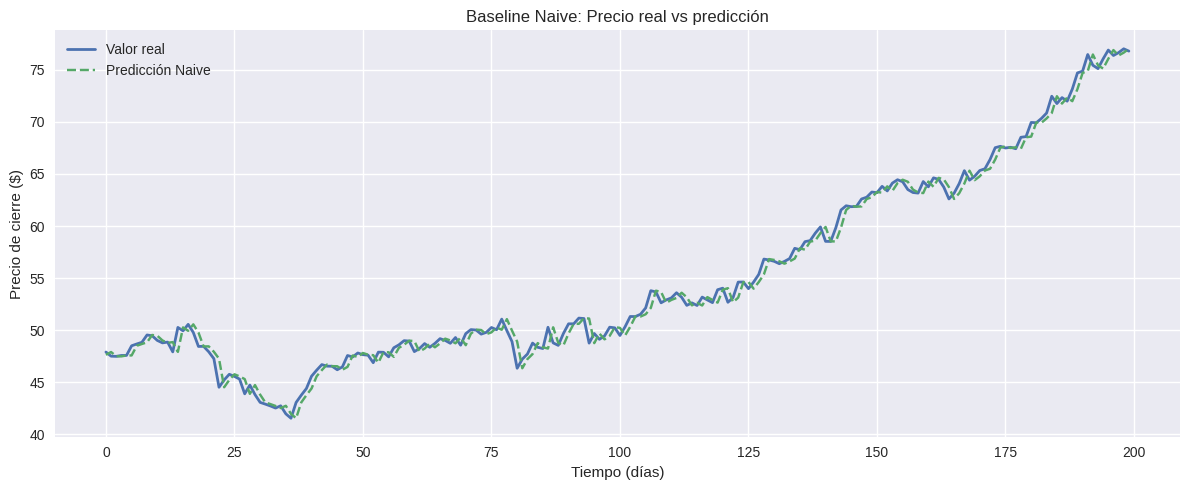

In [14]:
import matplotlib.pyplot as plt

# Número de puntos a visualizar
N_PLOT = 200

# Seleccionamos un tramo del test
y_real_plot = y_test_real[:N_PLOT]
y_pred_plot = y_pred_naive_real[:N_PLOT]

plt.figure(figsize=(12, 5))
plt.plot(y_real_plot, label="Valor real", linewidth=2)
plt.plot(y_pred_plot, label="Predicción Naive", linestyle="--")

plt.title("Baseline Naive: Precio real vs predicción")
plt.xlabel("Tiempo (días)")
plt.ylabel("Precio de cierre ($)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## **Baseline 2: Moving average (MA)**

El modelo de media móvil se define como:

$$
\hat{y}_t = \frac{1}{k} \sum_{i=1}^{k} y_{t-i}
$$

donde $k$ es el tamaño de la ventana temporal y $y_{t-i}$ representa los valores observados en instantes anteriores.

Con el fin de garantizar una comparación justa entre baselines, se emplea el mismo tamaño de ventana temporal utilizado en el modelo de persistencia.

In [15]:
# =========================
# PASO 7: Moving Average baseline
# =========================

CLOSE_IDX = FEATURES.index("close")

# Media de los últimos k valores de 'close'
y_pred_ma = X_test[:, :, CLOSE_IDX].mean(axis=1)

# Métricas en escala normalizada
mae_ma = mean_absolute_error(y_test, y_pred_ma)
rmse_ma = np.sqrt(mean_squared_error(y_test, y_pred_ma))
smape_ma = smape(y_test, y_pred_ma)

print("MOVING AVERAGE BASELINE (escala normalizada)")
print(f"MAE:  {mae_ma:.6f}")
print(f"RMSE: {rmse_ma:.6f}")
print(f"sMAPE: {smape_ma:.4f}%")

MOVING AVERAGE BASELINE (escala normalizada)
MAE:  0.019774
RMSE: 0.025186
sMAPE: 3.9208%


In [16]:
# Invertimos escalado
y_pred_ma_real = scaler_y.inverse_transform(y_pred_ma.reshape(-1,1)).flatten()

mae_ma_real = mean_absolute_error(y_test_real, y_pred_ma_real)
rmse_ma_real = np.sqrt(mean_squared_error(y_test_real, y_pred_ma_real))
smape_ma_real = smape(y_test_real, y_pred_ma_real)

print("\nMOVING AVERAGE BASELINE (escala real)")
print(f"MAE:  {mae_ma_real:.4f} $")
print(f"RMSE: {rmse_ma_real:.4f} $")
print(f"sMAPE: {smape_ma_real:.4f}%")


MOVING AVERAGE BASELINE (escala real)
MAE:  5.6584 $
RMSE: 7.2072 $
sMAPE: 3.9195%


El modelo de media móvil presenta un rendimiento significativamente inferior al modelo de persistencia, con un aumento notable del error en todas las métricas consideradas.

Este resultado indica que el suavizado temporal introducido por la media móvil elimina información relevante para la predicción del precio de cierre, sugiriendo que la serie presenta una fuerte dependencia del valor más reciente y una dinámica que no se beneficia del promediado de observaciones pasadas.

## **Baseline 3: Ridge regression**

El modelo Ridge Regression estima una relación lineal entre las variables de entrada y la variable objetivo, incorporando un término de regularización $L_2$ sobre los pesos:

$$
\hat{y}_t = \mathbf{w}^\top X_t + b
$$

donde los parámetros $\mathbf{w}$ y $b$ se obtienen resolviendo:

$$
\min_{\mathbf{w}, b} \sum_{i=1}^{N} (y_i - \mathbf{w}^\top X_i - b)^2 + \lambda \|\mathbf{w}\|_2^2
$$

siendo $\lambda$ el coeficiente de regularización.

Cada ventana temporal $X_t \in \mathbb{R}^{k \times d}$ se reestructura como un vector $\tilde{X}_t \in \mathbb{R}^{k \cdot d}$ antes de ser introducida en el modelo lineal.

In [17]:
# =========================
# PASO 8.1: Flatten de ventanas
# =========================

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print("X_train_flat:", X_train_flat.shape)
print("X_val_flat:  ", X_val_flat.shape)
print("X_test_flat: ", X_test_flat.shape)

X_train_flat: (7942, 100)
X_val_flat:   (1701, 100)
X_test_flat:  (1703, 100)


In [18]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_flat, y_train)

Ridge()

In [19]:
y_pred_ridge = ridge.predict(X_test_flat)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
smape_ridge = smape(y_test, y_pred_ridge)

print("RIDGE BASELINE (escala normalizada)")
print(f"MAE:  {mae_ridge:.6f}")
print(f"RMSE: {rmse_ridge:.6f}")
print(f"sMAPE: {smape_ridge:.4f}%")


RIDGE BASELINE (escala normalizada)
MAE:  0.019151
RMSE: 0.024493
sMAPE: 3.7826%


In [20]:
y_pred_ridge_real = scaler_y.inverse_transform(y_pred_ridge.reshape(-1,1)).flatten()

mae_ridge_real = mean_absolute_error(y_test_real, y_pred_ridge_real)
rmse_ridge_real = np.sqrt(mean_squared_error(y_test_real, y_pred_ridge_real))
smape_ridge_real = smape(y_test_real, y_pred_ridge_real)

print("\nRIDGE BASELINE (escala real)")
print(f"MAE:  {mae_ridge_real:.4f} $")
print(f"RMSE: {rmse_ridge_real:.4f} $")
print(f"sMAPE: {smape_ridge_real:.4f}%")



RIDGE BASELINE (escala real)
MAE:  5.4801 $
RMSE: 7.0087 $
sMAPE: 3.7813%


**Tabla X.** Comparación del rendimiento de los modelos baseline sobre el conjunto de prueba en escala real.

$$
\begin{array}{lccc}
\hline
\textbf{Modelo} & \textbf{MAE (\$)} & \textbf{RMSE (\$)} & \textbf{sMAPE (\%)} \\
\hline
\text{Naive (Persistencia)} & 1.95 & 2.83 & 1.35 \\
\text{Moving Average }(k=20) & 5.66 & 7.21 & 3.92 \\
\text{Ridge Regression} & 5.48 & 7.01 & 3.78 \\
\hline
\end{array}
$$


Dado que los modelos baseline basados en suavizado y relaciones lineales no logran mejorar el rendimiento del modelo de persistencia, se procede a evaluar un modelo capaz de capturar dependencias temporales no lineales y de mayor complejidad.


## **Modelo LSTM Simple**

El modelo LSTM recibe como entrada una secuencia temporal $X_t \in \mathbb{R}^{k \times d}$ y produce una predicción escalar $\hat{y}_t$:

$$
\hat{y}_t = f_{\text{LSTM}}(X_t)
$$

donde $f_{\text{LSTM}}(\cdot)$ representa una red neuronal recurrente capaz de modelar dependencias temporales no lineales.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Dimensiones de entrada
TIME_STEPS = X_train.shape[1]   # 20
N_FEATURES = X_train.shape[2]   # 5

model = Sequential([
    LSTM(32, input_shape=(TIME_STEPS, N_FEATURES)),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

El modelo se entrena minimizando el error cuadrático medio (MSE) sobre el conjunto de entrenamiento y se monitoriza el rendimiento sobre el conjunto de validación.  
Para reducir el riesgo de sobreajuste, se utiliza *early stopping*, deteniendo el entrenamiento cuando la pérdida de validación no mejora tras un número determinado de épocas.

La función de pérdida utilizada es el error cuadrático medio:

$$
\mathcal{L}_{\text{MSE}} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$

In [22]:
import tensorflow as tf

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.4011e-05 - val_loss: 8.4737e-06
Epoch 2/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.9366e-07 - val_loss: 8.3951e-06
Epoch 3/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 3.3112e-07 - val_loss: 8.1883e-06
Epoch 4/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3.5377e-07 - val_loss: 9.7565e-06
Epoch 5/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 4.2298e-07 - val_loss: 1.0571e-05
Epoch 6/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 4.0409e-07 - val_loss: 1.0594e-05
Epoch 7/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 3.7051e-07 - val_loss: 1.0706e-05
Epoch 8/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 3.3868e-07 - val_loss: 1.1092e-05
Epoch 9/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 3.0970e-07 - val_loss: 1.1328e-05
Epoch 10/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.8657e-07 - val_loss: 1.1411e-05
Epoch 11/100
249/249 ━━━━━━━━━━━━━━━━━━

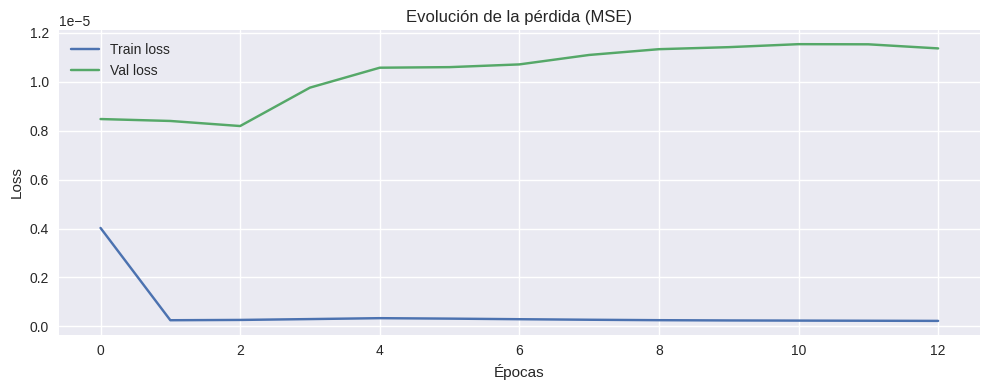

In [23]:
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.title("Evolución de la pérdida (MSE)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

La Figura X muestra la evolución de la función de pérdida durante el entrenamiento del modelo LSTM.
Se observa una rápida disminución del error en el conjunto de entrenamiento, mientras que el error de validación permanece significativamente más alto y presenta una tendencia creciente tras las primeras épocas.

Este comportamiento indica una falta de generalización del modelo y sugiere la presencia de sobreajuste temprano, lo que pone de manifiesto la dificultad de capturar patrones temporales estables en la serie analizada mediante este enfoque.

Una vez entrenado el modelo, se evalúa sobre el conjunto de prueba (*test set*), que contiene observaciones no vistas durante el entrenamiento ni la validación.  
Para interpretar los resultados en unidades reales, se invierte la normalización aplicada al objetivo.

In [24]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Predicción en test (salida en escala normalizada)
y_pred_lstm = model.predict(X_test).flatten()

# 2) Métricas en escala normalizada
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))

def smape(y_true, y_pred):
    eps = 1e-8
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + eps))

smape_lstm = smape(y_test, y_pred_lstm)

print("LSTM (escala normalizada)")
print(f"MAE:  {mae_lstm:.6f}")
print(f"RMSE: {rmse_lstm:.6f}")
print(f"sMAPE: {smape_lstm:.4f}%")

# 3) Invertir escalado a valores reales ($)
y_pred_lstm_real = scaler_y.inverse_transform(y_pred_lstm.reshape(-1,1)).flatten()

# y_test_real ya lo tenías calculado antes; si no, lo recalculamos:
y_test_real = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()

# 4) Métricas en escala real ($)
mae_lstm_real = mean_absolute_error(y_test_real, y_pred_lstm_real)
rmse_lstm_real = np.sqrt(mean_squared_error(y_test_real, y_pred_lstm_real))
smape_lstm_real = smape(y_test_real, y_pred_lstm_real)

print("\nLSTM (escala real)")
print(f"MAE:  {mae_lstm_real:.4f} $")
print(f"RMSE: {rmse_lstm_real:.4f} $")
print(f"sMAPE: {smape_lstm_real:.4f}%")

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
LSTM (escala normalizada)
MAE:  0.089697
RMSE: 0.116781
sMAPE: 15.2394%

LSTM (escala real)
MAE:  25.6670 $
RMSE: 33.4172 $
sMAPE: 15.2357%


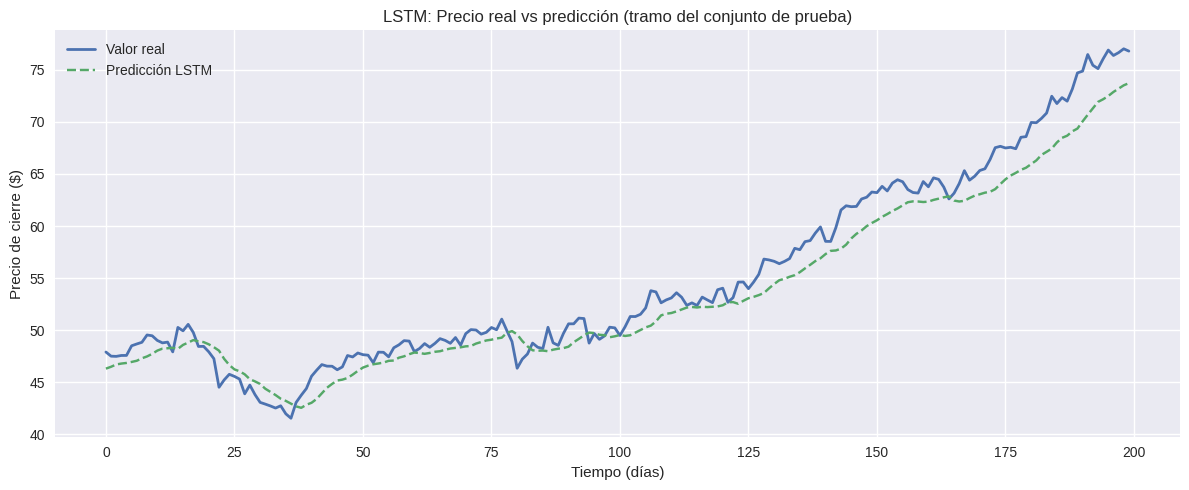

In [25]:
import matplotlib.pyplot as plt

N_PLOT = 200  # puedes subirlo a 500 si quieres

plt.figure(figsize=(12,5))
plt.plot(y_test_real[:N_PLOT], label="Valor real", linewidth=2)
plt.plot(y_pred_lstm_real[:N_PLOT], label="Predicción LSTM", linestyle="--")

plt.title("LSTM: Precio real vs predicción (tramo del conjunto de prueba)")
plt.xlabel("Tiempo (días)")
plt.ylabel("Precio de cierre ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Los resultados obtenidos muestran que el modelo LSTM presenta un rendimiento significativamente inferior al de los modelos baseline, con errores considerablemente mayores en todas las métricas evaluadas.

Aunque el modelo es capaz de seguir la tendencia general de la serie, no logra reproducir adecuadamente el nivel absoluto del precio ni anticipar variaciones relevantes, lo que se traduce en una acumulación progresiva del error a lo largo del tiempo.

Estos resultados indican que, para el objetivo de predicción planteado, el modelo LSTM no aporta mejoras respecto a enfoques más simples basados en persistencia.

En lugar de predecir el precio absoluto, se reformula el problema para predecir el retorno diario (*simple return*):

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

donde $P_t$ representa el precio de cierre en el instante $t$.

In [26]:
# =========================
# PASO 10.2: crear returns como nuevo target
# =========================

df = df.sort_values("date").reset_index(drop=True)

# Precio de cierre
P = df["close"].values

# r_t = (P_t - P_{t-1}) / P_{t-1}
returns = (P[1:] - P[:-1]) / (P[:-1] + 1e-12)

print("returns shape:", returns.shape)
print("Ejemplo returns:", returns[:5])

returns shape: (11365,)
Ejemplo returns: [-0.05217145 -0.07339731  0.02475089  0.02899244  0.06102871]


In [27]:
# =========================
# PASO 10.3: reconstruir X_raw y y_raw (returns)
# =========================

FEATURES = ["open", "high", "low", "close", "volume"]
X_raw = df[FEATURES].values

# y_raw_returns alineado a partir del índice 1
# returns[i] corresponde a cambio de P[i] respecto P[i-1]
y_raw_returns = returns  # longitud N-1

# Para que X y y tengan misma longitud, quitamos el último día de X_raw
# X_raw[:-1] se alinea con returns (que termina en el penúltimo índice)
X_raw_ret = X_raw[:-1]

print("X_raw_ret:", X_raw_ret.shape)
print("y_raw_returns:", y_raw_returns.shape)

X_raw_ret: (11365, 5)
y_raw_returns: (11365,)


In [28]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler_X = MinMaxScaler()
X_scaled_ret = scaler_X.fit_transform(X_raw_ret)

scaler_y_ret = StandardScaler()
y_scaled_ret = scaler_y_ret.fit_transform(y_raw_returns.reshape(-1,1)).flatten()

print("X_scaled_ret:", X_scaled_ret.shape)
print("y_scaled_ret:", y_scaled_ret.shape)

X_scaled_ret: (11365, 5)
y_scaled_ret: (11365,)


In [29]:
WINDOW_SIZE = 20

X_seq_ret, y_seq_ret = create_sliding_windows(X_scaled_ret, y_scaled_ret, window_size=WINDOW_SIZE)

N = len(X_seq_ret)
train_size = int(0.7 * N)
val_size = int(0.15 * N)

X_train_r = X_seq_ret[:train_size]
y_train_r = y_seq_ret[:train_size]

X_val_r = X_seq_ret[train_size:train_size+val_size]
y_val_r = y_seq_ret[train_size:train_size+val_size]

X_test_r = X_seq_ret[train_size+val_size:]
y_test_r = y_seq_ret[train_size+val_size:]

print("Train:", X_train_r.shape, y_train_r.shape)
print("Val:  ", X_val_r.shape, y_val_r.shape)
print("Test: ", X_test_r.shape, y_test_r.shape)


Train: (7941, 20, 5) (7941,)
Val:   (1701, 20, 5) (1701,)
Test:  (1703, 20, 5) (1703,)


In [30]:
# Baseline: return predicho = 0 (en escala estandarizada equivale a -mean/std, pero mejor hacerlo en real)
y_test_ret_real = scaler_y_ret.inverse_transform(y_test_r.reshape(-1,1)).flatten()
y_pred_zero_real = np.zeros_like(y_test_ret_real)

mae0 = mean_absolute_error(y_test_ret_real, y_pred_zero_real)
rmse0 = np.sqrt(mean_squared_error(y_test_ret_real, y_pred_zero_real))
smape0 = smape(y_test_ret_real, y_pred_zero_real)

print("Baseline returns (pred=0) en escala real")
print(f"MAE: {mae0:.6f}")
print(f"RMSE:{rmse0:.6f}")
print(f"sMAPE:{smape0:.4f}%")

Baseline returns (pred=0) en escala real
MAE: 0.013544
RMSE:0.019547
sMAPE:199.5295%


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

model_r = Sequential([
    LSTM(32, input_shape=(X_train_r.shape[1], X_train_r.shape[2])),
    Dense(1)
])

model_r.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history_r = model_r.fit(
    X_train_r, y_train_r,
    validation_data=(X_val_r, y_val_r),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 1.2109 - val_loss: 0.3372
Epoch 2/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.2107 - val_loss: 0.3372
Epoch 3/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.2104 - val_loss: 0.3374
Epoch 4/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.2103 - val_loss: 0.3376
Epoch 5/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.2103 - val_loss: 0.3377
Epoch 6/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 1.2102 - val_loss: 0.3378
Epoch 7/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.2102 - val_loss: 0.3379
Epoch 8/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.2101 - val_loss: 0.3380
Epoch 9/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.2101 - val_loss: 0.3381
Epoch 10/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 1.2101 - val_loss: 0.3381
Epoch 11/100
249/249 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 1.2101 - val_loss: 0.3382


In [32]:
# =========================
# Evaluación LSTM returns en test
# =========================

# 1) Predicción en test (escala estandarizada)
y_pred_r = model_r.predict(X_test_r).flatten()

# 2) Invertir escalado a returns reales
y_test_ret_real = scaler_y_ret.inverse_transform(y_test_r.reshape(-1,1)).flatten()
y_pred_ret_real = scaler_y_ret.inverse_transform(y_pred_r.reshape(-1,1)).flatten()

# 3) Métricas MAE/RMSE en escala real
mae_lstm_ret = mean_absolute_error(y_test_ret_real, y_pred_ret_real)
rmse_lstm_ret = np.sqrt(mean_squared_error(y_test_ret_real, y_pred_ret_real))

print("LSTM returns (escala real)")
print(f"MAE:  {mae_lstm_ret:.6f}")
print(f"RMSE: {rmse_lstm_ret:.6f}")

# 4) Métrica extra útil en returns: Directional Accuracy (DA)
# porcentaje de veces que acierta el signo del retorno
da = np.mean(np.sign(y_test_ret_real) == np.sign(y_pred_ret_real)) * 100
print(f"Directional Accuracy (signo): {da:.2f}%")


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
LSTM returns (escala real)
MAE:  0.014257
RMSE: 0.020083
Directional Accuracy (signo): 53.20%


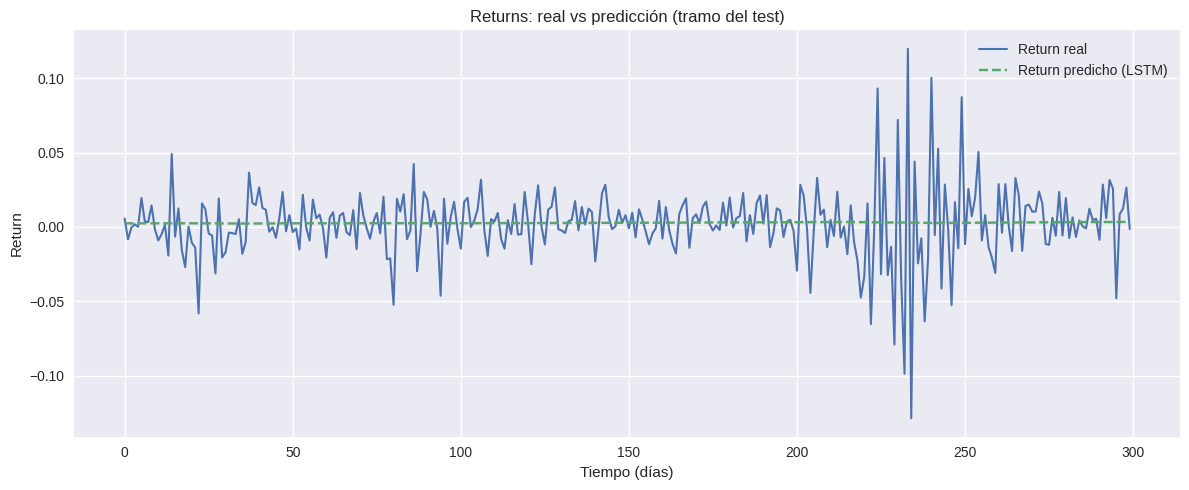

In [33]:
import matplotlib.pyplot as plt

N_PLOT = 300

plt.figure(figsize=(12,5))
plt.plot(y_test_ret_real[:N_PLOT], label="Return real", linewidth=1.5)
plt.plot(y_pred_ret_real[:N_PLOT], label="Return predicho (LSTM)", linestyle="--")
plt.title("Returns: real vs predicción (tramo del test)")
plt.xlabel("Tiempo (días)")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Aunque los modelos LSTM presentan una mayor capacidad de modelado, los resultados experimentales muestran que dicha complejidad no se traduce en una mejora del rendimiento predictivo frente a modelos baseline simples, lo que sugiere que la señal presente en los datos es débil o está dominada por ruido.